<a href="https://colab.research.google.com/github/jshen130/pytorch_colab/blob/main/BottleRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workflow
## Option 1 - Direct ingestion
- Read image file as 640x480 input array.
- Crop to reduce size and remove noise.
- Pros: simplicity

## Option 2 - Feature extraction
- Run sliding window / edge detection use as inputs.
- Pros: accuracy if done right.

In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as transforms
import torchvision.io as tv_io

import glob
from PIL import Image

device = torch.device("cpu")

# Data Ingestion

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
base_dir = "/content/drive/MyDrive/[TY] Docs/圖片-影像辨識/"
allowed_pet = "PET瓶-允收"
rejected_pet_other = "PET瓶-不允收-屬PET材質.需排除拒收"
rejected_non_pet = "PET瓶-不允收-非PET材質"
rejected_can = "鋁罐-不允收-部分含鋁材.需排除拒收"
allowed_can = "鋁罐-允收"

DATA_LABELS = [rejected_can]  # [allowed_pet, rejected_pet_other, rejected_non_pet, rejected_can, allowed_can]

In [28]:
from pathlib import Path
path = Path('/content/drive/MyDrive/[TY] Docs/圖片-影像辨識/鋁罐-不允收-部分含鋁材.需排除拒收/')
files = list(path.rglob('*.jpg')) # rglob is recursive by default

In [32]:
import matplotlib.pyplot as plt

# Permute to (H, W, C) and convert to numpy for matplotlib

# Helper data structures
class MyDataset(Dataset):
    def __init__(self, data_dir, pre_transformer = lambda x:x, filetype = "jpg"):
        self.imgs = []
        self.labels = []

        for l_idx, label in enumerate(DATA_LABELS):
            path = Path(f'{base_dir}/{label}/')
            data_paths = list(path.rglob('*.jpg'))
            # data_paths = glob.glob("", recursive=True)
            print(data_paths)
            for path in data_paths:
                img = tv_io.read_image(path, tv_io.ImageReadMode.RGB)
                print(img)
                plt.imshow(img.permute(1, 2, 0))
                plt.show()

                self.imgs.append(pre_transformer(img).to(device))
                self.labels.append(torch.tensor(l_idx).to(device))


    def __getitem__(self, idx):
        img = self.imgs[idx]
        label = self.labels[idx]
        return img, label

    def __len__(self):
        return len(self.imgs)

[PosixPath('/content/drive/MyDrive/[TY] Docs/圖片-影像辨識/鋁罐-不允收-部分含鋁材.需排除拒收/F6_2026_03_05_14_21_28.jpg'), PosixPath('/content/drive/MyDrive/[TY] Docs/圖片-影像辨識/鋁罐-不允收-部分含鋁材.需排除拒收/F5_2026_03_05_14_37_48.jpg'), PosixPath('/content/drive/MyDrive/[TY] Docs/圖片-影像辨識/鋁罐-不允收-部分含鋁材.需排除拒收/F5_2026_03_05_14_37_56.jpg'), PosixPath('/content/drive/MyDrive/[TY] Docs/圖片-影像辨識/鋁罐-不允收-部分含鋁材.需排除拒收/F5_2026_03_05_14_38_01.jpg'), PosixPath('/content/drive/MyDrive/[TY] Docs/圖片-影像辨識/鋁罐-不允收-部分含鋁材.需排除拒收/F5_2026_03_05_14_38_04.jpg'), PosixPath('/content/drive/MyDrive/[TY] Docs/圖片-影像辨識/鋁罐-不允收-部分含鋁材.需排除拒收/F5_2026_03_05_14_38_43.jpg'), PosixPath('/content/drive/MyDrive/[TY] Docs/圖片-影像辨識/鋁罐-不允收-部分含鋁材.需排除拒收/F6_2026_03_05_14_38_50.jpg'), PosixPath('/content/drive/MyDrive/[TY] Docs/圖片-影像辨識/鋁罐-不允收-部分含鋁材.需排除拒收/F6_2026_03_05_14_38_55.jpg'), PosixPath('/content/drive/MyDrive/[TY] Docs/圖片-影像辨識/鋁罐-不允收-部分含鋁材.需排除拒收/F6_2026_03_05_14_40_20.jpg'), PosixPath('/content/drive/MyDrive/[TY] Docs/圖片-影像辨識/鋁罐-不允收-部分含鋁材.需排除拒收/F6_2026_03_05_14_40

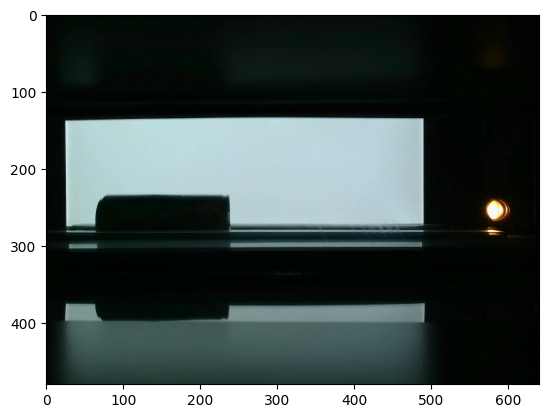

tensor([[[3, 3, 3,  ..., 0, 0, 1],
         [2, 2, 2,  ..., 0, 0, 0],
         [2, 2, 3,  ..., 1, 1, 2],
         ...,
         [3, 3, 3,  ..., 0, 1, 1],
         [3, 3, 3,  ..., 0, 2, 2],
         [3, 3, 3,  ..., 0, 1, 1]],

        [[4, 4, 4,  ..., 4, 5, 6],
         [3, 3, 3,  ..., 4, 4, 5],
         [3, 3, 3,  ..., 3, 3, 4],
         ...,
         [7, 7, 9,  ..., 2, 3, 3],
         [7, 7, 9,  ..., 2, 2, 2],
         [7, 7, 9,  ..., 2, 1, 1]],

        [[6, 6, 6,  ..., 0, 1, 2],
         [5, 5, 5,  ..., 0, 0, 1],
         [5, 5, 5,  ..., 0, 0, 1],
         ...,
         [8, 8, 9,  ..., 0, 0, 0],
         [8, 8, 9,  ..., 0, 0, 0],
         [8, 8, 9,  ..., 0, 0, 0]]], dtype=torch.uint8)


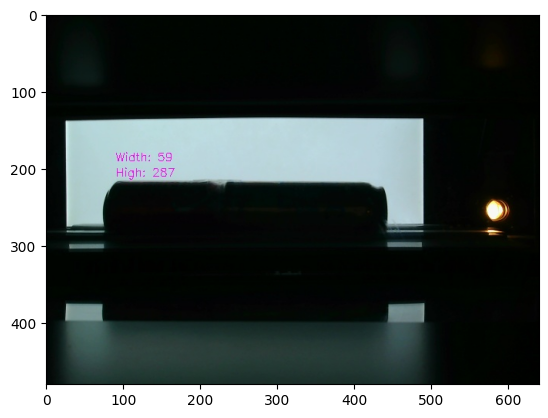

tensor([[[3, 3, 3,  ..., 1, 3, 3],
         [3, 3, 3,  ..., 1, 2, 2],
         [3, 3, 3,  ..., 0, 0, 1],
         ...,
         [3, 3, 3,  ..., 2, 1, 1],
         [3, 3, 2,  ..., 2, 1, 1],
         [3, 3, 2,  ..., 2, 1, 1]],

        [[3, 3, 3,  ..., 3, 3, 3],
         [3, 3, 3,  ..., 3, 2, 2],
         [3, 3, 3,  ..., 2, 2, 3],
         ...,
         [7, 7, 9,  ..., 2, 1, 1],
         [7, 7, 8,  ..., 2, 1, 1],
         [7, 7, 8,  ..., 2, 1, 1]],

        [[5, 5, 5,  ..., 0, 1, 1],
         [5, 5, 5,  ..., 0, 0, 0],
         [5, 5, 5,  ..., 0, 0, 0],
         ...,
         [8, 8, 9,  ..., 0, 0, 0],
         [8, 8, 8,  ..., 0, 0, 0],
         [8, 8, 8,  ..., 0, 0, 0]]], dtype=torch.uint8)


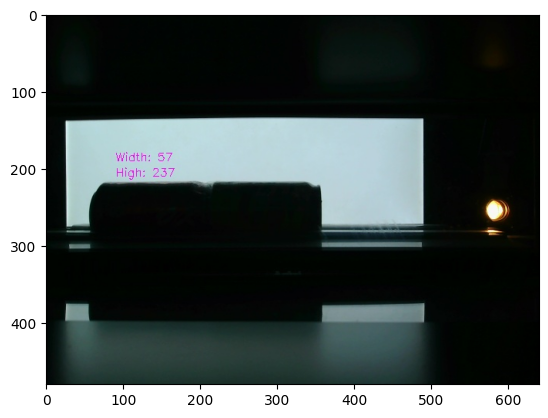

tensor([[[3, 3, 3,  ..., 0, 0, 0],
         [3, 3, 3,  ..., 0, 0, 0],
         [3, 3, 3,  ..., 0, 0, 0],
         ...,
         [3, 3, 3,  ..., 1, 1, 1],
         [3, 3, 3,  ..., 1, 1, 1],
         [3, 3, 2,  ..., 1, 1, 1]],

        [[3, 3, 3,  ..., 5, 5, 5],
         [3, 3, 3,  ..., 4, 4, 4],
         [3, 3, 3,  ..., 4, 4, 4],
         ...,
         [7, 7, 9,  ..., 1, 1, 1],
         [7, 7, 9,  ..., 1, 1, 1],
         [7, 7, 8,  ..., 1, 1, 1]],

        [[5, 5, 5,  ..., 1, 1, 1],
         [5, 5, 5,  ..., 0, 0, 0],
         [5, 5, 5,  ..., 0, 0, 0],
         ...,
         [6, 6, 7,  ..., 0, 0, 0],
         [6, 6, 7,  ..., 0, 0, 0],
         [6, 6, 6,  ..., 0, 0, 0]]], dtype=torch.uint8)


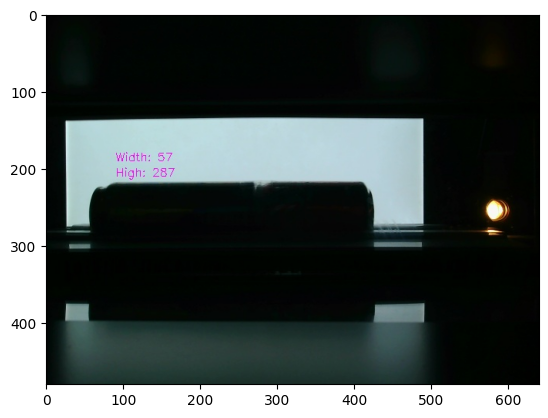

tensor([[[4, 4, 4,  ..., 2, 2, 2],
         [3, 3, 3,  ..., 2, 1, 1],
         [3, 3, 3,  ..., 1, 1, 1],
         ...,
         [3, 3, 3,  ..., 1, 1, 0],
         [3, 3, 3,  ..., 0, 0, 0],
         [3, 3, 3,  ..., 0, 0, 0]],

        [[4, 4, 4,  ..., 4, 4, 4],
         [3, 3, 3,  ..., 4, 3, 3],
         [3, 3, 3,  ..., 3, 3, 3],
         ...,
         [7, 7, 9,  ..., 3, 3, 2],
         [7, 7, 9,  ..., 2, 2, 2],
         [7, 7, 9,  ..., 2, 2, 1]],

        [[6, 6, 6,  ..., 0, 0, 0],
         [5, 5, 5,  ..., 0, 0, 0],
         [5, 5, 5,  ..., 0, 0, 0],
         ...,
         [8, 8, 9,  ..., 2, 2, 1],
         [8, 8, 9,  ..., 1, 1, 1],
         [8, 8, 9,  ..., 1, 1, 0]]], dtype=torch.uint8)


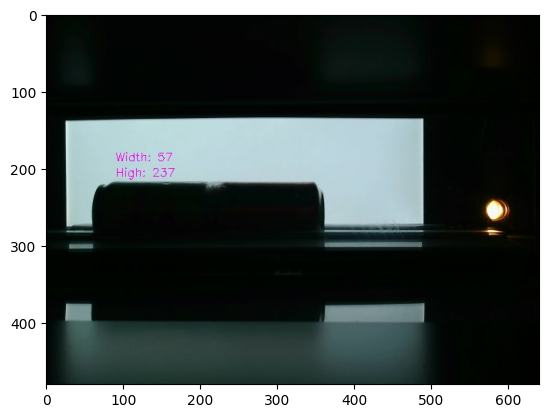

tensor([[[4, 4, 4,  ..., 2, 2, 2],
         [4, 4, 4,  ..., 2, 2, 2],
         [4, 4, 4,  ..., 2, 2, 2],
         ...,
         [3, 2, 3,  ..., 0, 0, 0],
         [3, 2, 3,  ..., 1, 1, 0],
         [2, 2, 3,  ..., 1, 1, 1]],

        [[4, 4, 4,  ..., 4, 4, 4],
         [4, 4, 4,  ..., 4, 4, 4],
         [4, 4, 4,  ..., 4, 4, 4],
         ...,
         [7, 8, 9,  ..., 2, 2, 2],
         [7, 8, 9,  ..., 3, 3, 2],
         [6, 8, 9,  ..., 3, 3, 3]],

        [[6, 6, 4,  ..., 0, 0, 0],
         [6, 6, 4,  ..., 0, 0, 0],
         [4, 4, 4,  ..., 1, 1, 1],
         ...,
         [8, 8, 9,  ..., 0, 0, 0],
         [8, 8, 9,  ..., 0, 0, 0],
         [7, 8, 9,  ..., 0, 0, 0]]], dtype=torch.uint8)


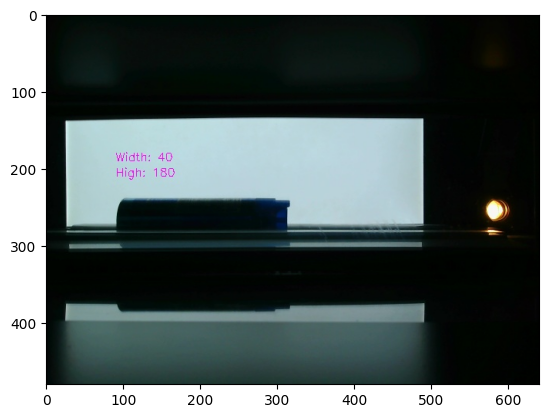

tensor([[[3, 3, 3,  ..., 2, 1, 1],
         [3, 3, 3,  ..., 2, 1, 1],
         [3, 3, 4,  ..., 1, 1, 1],
         ...,
         [3, 3, 3,  ..., 0, 0, 0],
         [3, 3, 3,  ..., 1, 1, 1],
         [3, 3, 3,  ..., 1, 1, 1]],

        [[3, 3, 5,  ..., 4, 3, 3],
         [3, 3, 5,  ..., 4, 3, 3],
         [3, 3, 4,  ..., 3, 3, 3],
         ...,
         [7, 7, 9,  ..., 2, 2, 2],
         [7, 7, 9,  ..., 3, 3, 3],
         [7, 7, 9,  ..., 3, 3, 3]],

        [[5, 5, 4,  ..., 1, 0, 0],
         [5, 5, 4,  ..., 1, 0, 0],
         [5, 5, 4,  ..., 0, 0, 0],
         ...,
         [8, 8, 9,  ..., 0, 0, 0],
         [8, 8, 9,  ..., 0, 0, 0],
         [8, 8, 9,  ..., 0, 0, 0]]], dtype=torch.uint8)


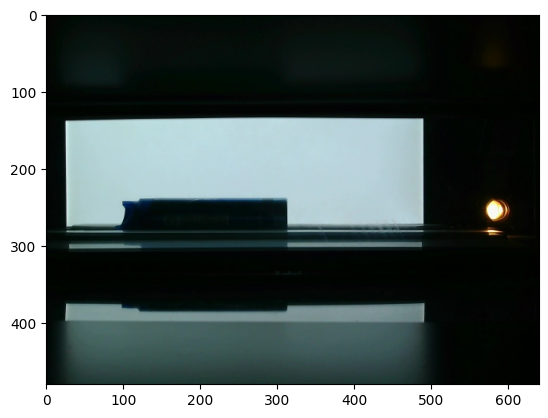

tensor([[[5, 5, 4,  ..., 3, 3, 3],
         [5, 4, 3,  ..., 2, 2, 2],
         [3, 3, 3,  ..., 2, 2, 2],
         ...,
         [3, 3, 3,  ..., 1, 0, 0],
         [2, 2, 3,  ..., 1, 1, 1],
         [2, 2, 3,  ..., 1, 1, 1]],

        [[3, 3, 4,  ..., 5, 5, 5],
         [3, 2, 3,  ..., 4, 4, 4],
         [3, 3, 3,  ..., 4, 4, 4],
         ...,
         [7, 7, 9,  ..., 3, 2, 2],
         [8, 8, 9,  ..., 3, 3, 3],
         [8, 8, 9,  ..., 3, 3, 3]],

        [[8, 8, 6,  ..., 2, 2, 2],
         [8, 7, 5,  ..., 1, 1, 1],
         [5, 5, 5,  ..., 1, 1, 1],
         ...,
         [8, 8, 9,  ..., 0, 0, 0],
         [8, 8, 9,  ..., 0, 0, 0],
         [8, 8, 9,  ..., 0, 0, 0]]], dtype=torch.uint8)


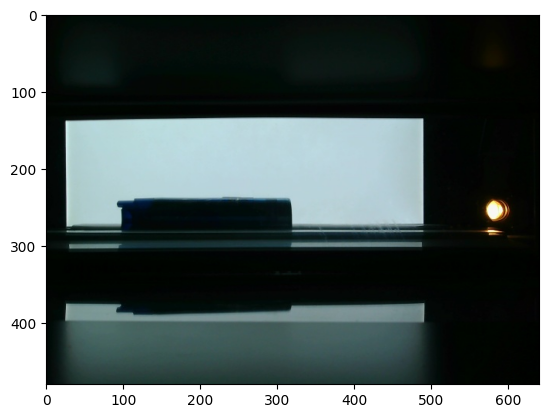

tensor([[[3, 3, 3,  ..., 2, 2, 2],
         [3, 3, 4,  ..., 1, 1, 1],
         [3, 3, 4,  ..., 2, 1, 1],
         ...,
         [2, 3, 3,  ..., 1, 2, 3],
         [2, 2, 3,  ..., 1, 2, 2],
         [2, 2, 2,  ..., 0, 0, 1]],

        [[2, 2, 3,  ..., 4, 4, 4],
         [2, 2, 4,  ..., 3, 3, 3],
         [3, 3, 4,  ..., 4, 3, 3],
         ...,
         [8, 9, 9,  ..., 3, 4, 5],
         [8, 8, 9,  ..., 3, 4, 4],
         [8, 8, 8,  ..., 2, 2, 3]],

        [[7, 7, 5,  ..., 1, 1, 1],
         [7, 7, 6,  ..., 0, 0, 0],
         [5, 5, 6,  ..., 1, 0, 0],
         ...,
         [8, 9, 9,  ..., 0, 1, 2],
         [8, 8, 9,  ..., 0, 1, 1],
         [8, 8, 8,  ..., 0, 0, 0]]], dtype=torch.uint8)


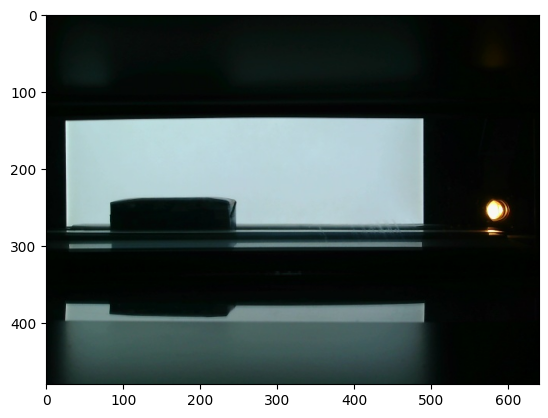

tensor([[[4, 4, 4,  ..., 3, 3, 4],
         [3, 4, 4,  ..., 2, 2, 3],
         [3, 4, 4,  ..., 1, 1, 1],
         ...,
         [4, 3, 3,  ..., 0, 1, 1],
         [6, 4, 3,  ..., 0, 2, 2],
         [6, 4, 4,  ..., 0, 1, 2]],

        [[4, 4, 4,  ..., 5, 5, 6],
         [3, 4, 4,  ..., 4, 4, 5],
         [3, 4, 4,  ..., 3, 3, 3],
         ...,
         [8, 7, 9,  ..., 2, 1, 1],
         [7, 8, 9,  ..., 2, 2, 2],
         [7, 8, 8,  ..., 2, 1, 2]],

        [[6, 6, 6,  ..., 2, 0, 1],
         [5, 6, 6,  ..., 1, 0, 0],
         [5, 6, 6,  ..., 0, 0, 0],
         ...,
         [9, 8, 9,  ..., 0, 0, 0],
         [9, 9, 9,  ..., 0, 0, 0],
         [9, 9, 9,  ..., 0, 0, 0]]], dtype=torch.uint8)


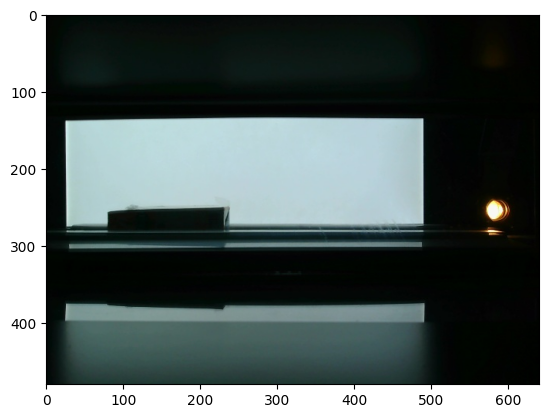

tensor([[[ 5,  5,  4,  ...,  3,  1,  2],
         [ 5,  4,  4,  ...,  3,  1,  0],
         [ 4,  4,  4,  ...,  2,  0,  0],
         ...,
         [ 4,  4,  3,  ...,  1,  2,  2],
         [ 4,  4,  3,  ...,  1,  1,  1],
         [ 5,  4,  3,  ...,  1,  1,  1]],

        [[ 3,  3,  2,  ...,  5,  6,  7],
         [ 3,  2,  2,  ...,  5,  6,  5],
         [ 2,  2,  2,  ...,  4,  4,  3],
         ...,
         [ 8,  8,  9,  ...,  1,  2,  2],
         [ 8,  8,  9,  ...,  1,  1,  1],
         [ 9,  8,  9,  ...,  1,  1,  1]],

        [[ 4,  4,  5,  ...,  0,  0,  1],
         [ 4,  3,  5,  ...,  0,  0,  0],
         [ 3,  3,  3,  ...,  0,  0,  0],
         ...,
         [ 9,  9,  9,  ...,  0,  0,  0],
         [ 9,  9,  9,  ...,  0,  0,  0],
         [10,  9,  9,  ...,  0,  0,  0]]], dtype=torch.uint8)


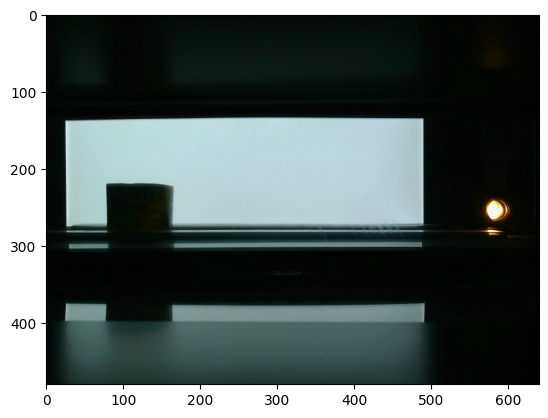

tensor([[[3, 4, 4,  ..., 0, 0, 0],
         [3, 3, 4,  ..., 0, 0, 0],
         [3, 3, 3,  ..., 0, 0, 0],
         ...,
         [3, 3, 3,  ..., 0, 0, 0],
         [3, 3, 3,  ..., 0, 0, 0],
         [3, 3, 3,  ..., 0, 0, 0]],

        [[3, 4, 4,  ..., 4, 5, 5],
         [3, 3, 4,  ..., 5, 5, 5],
         [3, 3, 3,  ..., 5, 5, 5],
         ...,
         [7, 7, 9,  ..., 3, 3, 4],
         [7, 7, 9,  ..., 4, 4, 4],
         [7, 7, 9,  ..., 3, 4, 4]],

        [[5, 6, 6,  ..., 0, 0, 0],
         [5, 5, 6,  ..., 0, 0, 0],
         [5, 5, 5,  ..., 0, 0, 0],
         ...,
         [8, 8, 9,  ..., 0, 0, 0],
         [8, 8, 9,  ..., 0, 0, 0],
         [8, 8, 9,  ..., 0, 0, 0]]], dtype=torch.uint8)


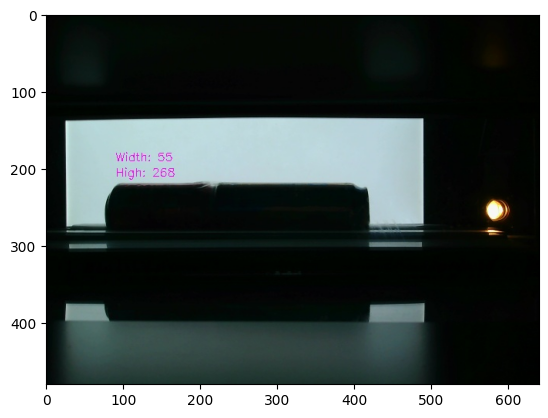

tensor([[[3, 4, 5,  ..., 2, 2, 2],
         [3, 4, 4,  ..., 1, 2, 2],
         [2, 3, 3,  ..., 1, 1, 2],
         ...,
         [5, 6, 4,  ..., 0, 1, 1],
         [5, 6, 4,  ..., 1, 1, 1],
         [5, 5, 4,  ..., 2, 1, 1]],

        [[3, 4, 5,  ..., 4, 4, 4],
         [3, 4, 4,  ..., 3, 4, 4],
         [2, 3, 3,  ..., 3, 3, 4],
         ...,
         [6, 7, 8,  ..., 0, 1, 1],
         [6, 7, 8,  ..., 1, 1, 1],
         [6, 6, 8,  ..., 2, 1, 1]],

        [[5, 6, 7,  ..., 1, 1, 1],
         [5, 6, 6,  ..., 0, 1, 1],
         [4, 5, 5,  ..., 0, 0, 1],
         ...,
         [8, 9, 9,  ..., 0, 1, 1],
         [8, 9, 9,  ..., 1, 1, 1],
         [8, 8, 9,  ..., 2, 1, 1]]], dtype=torch.uint8)


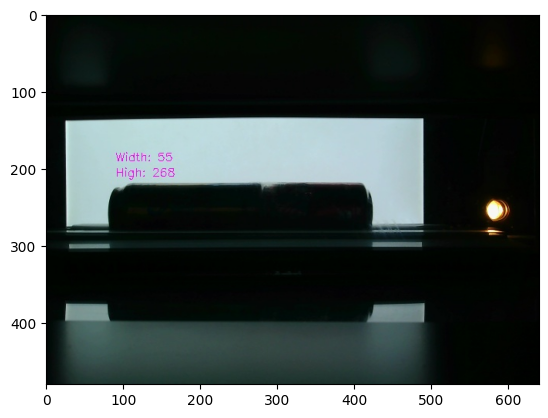

tensor([[[5, 5, 5,  ..., 3, 3, 2],
         [5, 5, 5,  ..., 3, 3, 3],
         [4, 4, 4,  ..., 2, 2, 2],
         ...,
         [3, 3, 3,  ..., 0, 1, 1],
         [2, 3, 3,  ..., 0, 1, 1],
         [3, 4, 3,  ..., 1, 1, 1]],

        [[5, 5, 5,  ..., 3, 3, 2],
         [5, 5, 5,  ..., 3, 3, 3],
         [4, 4, 4,  ..., 4, 4, 4],
         ...,
         [7, 7, 9,  ..., 2, 3, 3],
         [6, 7, 9,  ..., 2, 3, 3],
         [7, 8, 9,  ..., 3, 3, 3]],

        [[7, 7, 7,  ..., 1, 3, 2],
         [7, 7, 7,  ..., 1, 3, 3],
         [6, 6, 6,  ..., 1, 3, 3],
         ...,
         [8, 8, 9,  ..., 0, 0, 0],
         [7, 8, 9,  ..., 0, 0, 0],
         [8, 9, 9,  ..., 0, 0, 0]]], dtype=torch.uint8)


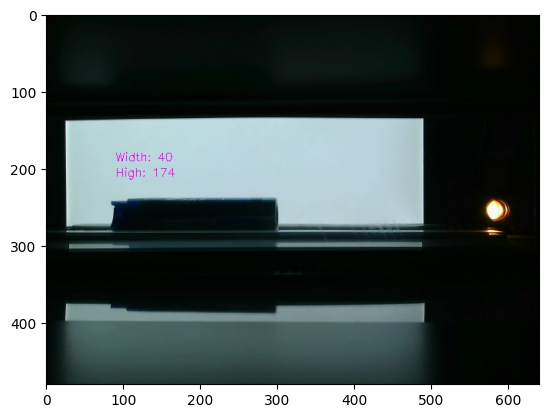

In [33]:

train_data = MyDataset(base_dir)
#/content/drive/MyDrive/[TY] Docs/圖片-影像辨識/鋁罐-不允收-部分含鋁材.需排除拒收/F5_2026_03_05_14_37_48.jpg

In [15]:
len(train_data)

0

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5) # 3 input channels (RGB), 6 filters
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(6 * 14 * 14, 2) # 2 output classes

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        return x

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True)


net = SimpleCNN()

# 3. Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

# 4. The Training Loop
for epoch in range(2): # Just 2 passes for a quick test
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        optimizer.zero_grad()   # Reset gradients
        outputs = net(inputs)    # Forward pass
        loss = criterion(outputs, labels) # Calculate error
        loss.backward()         # Backward pass (autograd)
        optimizer.step()        # Update weights

print('Finished Training!')